# 焊接工艺参数数据库 — 探索与可视化

**数据源: MongoDB 集合 `welding_dynamics.welding_parameters`** (localhost:27017)。
该集合由 [`project_data/ingest_mongo.py`](../project_data/ingest_mongo.py) 从原始工作簿
`Welding Process Parameter Database 2022_rev.2022.03.24.xlsx` (2022-03-24 修订) 解析并写入 —
xlsx 中"送丝设定(实际电流)"、双丝主/从、`一元化` 电压等格式已在导入时清洗为数值字段。

这是一份来自实际生产现场的 GMAW/MIG 焊接工艺参数数据库, 按"焊接记录 → 焊道"两级组织:
每条**记录**对应一个工件/接头的工艺规程 (设备、母材、坡口、位置等), 其下多行对应多道焊的**各焊道**参数 (电流、电压、速度、摆动)。

本 notebook 从 MongoDB 读回并可视化该数据库, 并总结其与本仿真包各模块的对应关系
(电弧自调节 `GMAWDynamics`、Goldak 热源 `GoldakFDM`、摆动/熔滴模块等)。

> 若集合尚未创建, 先在仓库根目录运行 `uv run python project_data/ingest_mongo.py`。


In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pymongo import MongoClient

# ---- 连接 MongoDB (与 project_data/ingest_mongo.py 同一接口) ----
MONGO = "mongodb://localhost:27017"
DB, COLL = "welding_dynamics", "welding_parameters"
coll = MongoClient(MONGO, serverSelectionTimeoutMS=5000)[DB][COLL]
assert coll.estimated_document_count() > 0, (
    "集合为空 — 请先在仓库根目录运行: uv run python project_data/ingest_mongo.py")

# 中文字体 (环境自带 Noto Sans CJK)
matplotlib.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "WenQuanYi Zen Hei", "SimHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

# 分类色板 (已通过 CVD/对比度校验的参考色板, 按固定顺序取用, 不循环)
C = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
INK, INK2, MUTED, GRID, BASE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": BASE, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, fontsize=11, loc="left", pad=8)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)

## 1. 集合总览

集合以 `doc_type` 区分三类文档:
- **`procedure`** — 一条焊接工艺记录, `passes` 数组内嵌各焊道 (已解析的 `current_A` / `voltage_V` / … 及原始 `*_raw`);
- **`weave_pattern`** — 摆动库路点波形;
- **`source_meta`** — 数据来源与录入规则 (原 xlsx"备注"表)。


In [2]:
summary = list(coll.aggregate([
    {"$group": {"_id": "$doc_type", "文档数": {"$sum": 1},
                "内嵌焊道数": {"$sum": {"$ifNull": ["$n_passes", 0]}}}},
    {"$sort": {"文档数": -1}},
]))
meta = coll.find_one({"doc_type": "source_meta"})
print(f"集合 {DB}.{COLL}: 共 {coll.estimated_document_count()} 文档 | "
      f"来源 {meta['source_file']} (rev {meta['revision']})")
pd.DataFrame(summary).rename(columns={"_id": "doc_type"}).set_index("doc_type")

集合 welding_dynamics.welding_parameters: 共 152 文档 | 来源 Welding Process Parameter Database 2022_rev.2022.03.24.xlsx (rev 2022.03.24)


,文档数,内嵌焊道数
doc_type,,
procedure,130,417
weave_pattern,21,0
source_meta,1,0


## 2. 载入 procedure 文档 → 记录 / 焊道两级 DataFrame

数值字段在导入时已清洗完毕 (`current_A`, `voltage_V`, `travel_speed_mm_s`,
`weave.frequency_Hz`, `weave.amplitude_mm`, `heat_input_J_mm`), 因此这里**不再需要正则解析** —
直接把内嵌的 `passes` 展开成焊道级 `df`, 再按记录聚合成记录级 `rec`。

- `记录号` = 文档 `record_id`; `道号` = `pass_no` (0 = 多道焊根道)。
- `voltage_synergic=True` 的焊道 (电源"一元化/协同"模式) 其 `voltage_V` 已为 `null`。


In [3]:
procs = list(coll.find({"doc_type": "procedure"}).sort("record_id", 1))

rec_rows, pass_rows = [], []
for d in procs:
    rid = d["record_id"]
    rec_rows.append({
        "记录号": rid, "焊机型号": d["machine"]["model_raw"], "厂商": d["machine"]["manufacturer"],
        "母材": d["base_metal"], "焊丝直径mm": d["wire"]["diameter_mm"], "焊丝种类": d["wire"]["type"],
        "保护气体": d["shielding_gas"], "焊缝形式": d["joint"]["seam_type"],
        "焊接位置": d["joint"]["position"], "焊脚尺寸": d["joint"]["leg_size"],
        "客户": d["source"]["customer"], "录入日期": d["source"]["entry_date"], "焊道数": d["n_passes"],
    })
    for p in d["passes"]:
        pass_rows.append({
            "记录号": rid, "母材": d["base_metal"], "道号": p["pass_no"],
            "电流A": p["current_A"], "电压V": p["voltage_V"], "速度mm/s": p["travel_speed_mm_s"],
            "热输入J/mm": p["heat_input_J_mm"],
            "摆频Hz": p["weave"]["frequency_Hz"], "摆幅mm": p["weave"]["amplitude_mm"],
        })

rec = pd.DataFrame(rec_rows).set_index("记录号")
df = pd.DataFrame(pass_rows)

print(f"记录数: {len(rec)}   焊道行数: {len(df)}")
print("每条记录的焊道数分布:")
print(rec["焊道数"].value_counts().sort_index().to_string())
rec[["焊机型号", "厂商", "母材", "焊丝直径mm", "保护气体", "焊缝形式", "焊接位置", "焊道数", "客户"]].head(8)

记录数: 130   焊道行数: 417
每条记录的焊道数分布:
焊道数
1     55
2     12
3     13
4     13
5      4
6     14
7     13
8      4
10     2


,焊机型号,厂商,母材,焊丝直径mm,保护气体,焊缝形式,焊接位置,焊道数,客户
记录号,,,,,,,,,
1,林肯R450,Lincoln,碳钢,1.2,82% Ar + 18% CO2,角接,平角焊,3,三一重装
2,林肯R450,Lincoln,碳钢,1.2,82% Ar + 18% CO2,角接,平角焊,4,三一重装
3,林肯R450,Lincoln,碳钢,1.2,82% Ar + 18% CO2,角接,平角焊,4,三一重装
4,林肯R450,Lincoln,碳钢,1.2,82% Ar + 18% CO2,角接,平角焊,7,三一重装
5,林肯R450,Lincoln,碳钢,1.2,82% Ar + 18% CO2,单V坡口,平焊,4,三一重装
6,林肯R450,Lincoln,碳钢,1.2,82% Ar + 18% CO2,单V坡口,平焊,4,三一重装
7,林肯R450,Lincoln,碳钢,1.2,82% Ar + 18% CO2,单V坡口,平焊,5,三一重装
8,林肯R450,Lincoln,碳钢,1.2,82% Ar + 18% CO2,单V坡口,平焊,5,三一重装


## 3. 设备与工况分布 (记录级)

`厂商` 已在导入时由型号归一 (如 "林肯R450"/"林肯450" → `Lincoln`, "福尼斯"/"伏能士" → `Fronius`),
这里只补一个中文显示名。


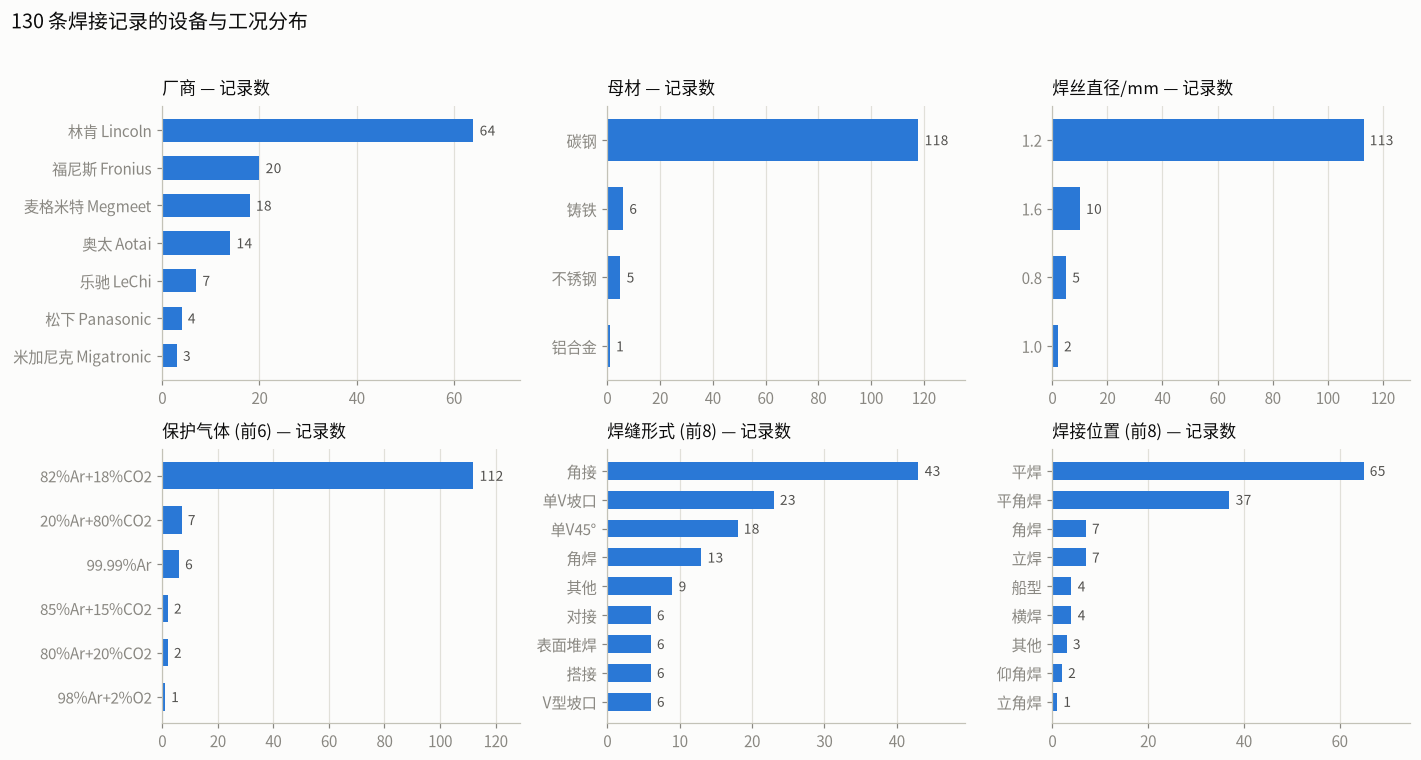

In [4]:
MFR_LABEL = {"Lincoln": "林肯 Lincoln", "Aotai": "奥太 Aotai", "Megmeet": "麦格米特 Megmeet",
             "Fronius": "福尼斯 Fronius", "LeChi": "乐驰 LeChi", "Panasonic": "松下 Panasonic",
             "Migatronic": "米加尼克 Migatronic", "other": "其他"}
rec["厂商名"] = rec["厂商"].map(lambda s: MFR_LABEL.get(s, s))
rec["气体"] = rec["保护气体"].astype(str).str.replace("氩气", "Ar").str.replace(" ", "")
rec["焊缝"] = rec["焊缝形式"].astype(str).str.replace("v", "V")
rec["丝径"] = rec["焊丝直径mm"].dropna().map("{:.1f}".format)

panels = [("厂商", rec["厂商名"]), ("母材", rec["母材"]), ("焊丝直径/mm", rec["丝径"]),
          ("保护气体 (前6)", rec["气体"]), ("焊缝形式 (前8)", rec["焊缝"]), ("焊接位置 (前8)", rec["焊接位置"])]
tops = [99, 99, 99, 6, 8, 8]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (title, s), top in zip(axes.ravel(), panels, tops):
    vc = s.value_counts()
    if len(vc) > top:
        vc = pd.concat([vc.head(top), pd.Series({"其他": vc.iloc[top:].sum()})])
    vc = vc.sort_values()
    ax.barh(vc.index.astype(str), vc.values, color=C[0], height=0.62)
    for y, v in enumerate(vc.values):
        ax.text(v + max(vc.values) * 0.02, y, str(v), va="center", color=INK2, fontsize=9)
    ax.set_xlim(0, max(vc.values) * 1.15)
    ax.grid(axis="y", visible=False)
    style_ax(ax, title=f"{title} — 记录数")
fig.suptitle(f"{len(rec)} 条焊接记录的设备与工况分布", color=INK, x=0.01, ha="left", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 4. 工艺窗口: 电流–电压 (焊道级)

每个点是一条焊道。按合理物理窗口过滤 (80–450 A, 10–45 V), 排除送丝设定被误当电流、
以及 `一元化`/CMT 修正值等无法解释为电弧电压的行。

这是电源"一元化/协同"曲线所在的平面 — 与模块 1 `GMAWDynamics` 的恒压特性 + 电弧自调节工作点直接对应。


参与绘图焊道: 365 / 417 (其余为缺失/一元化/无法解析)


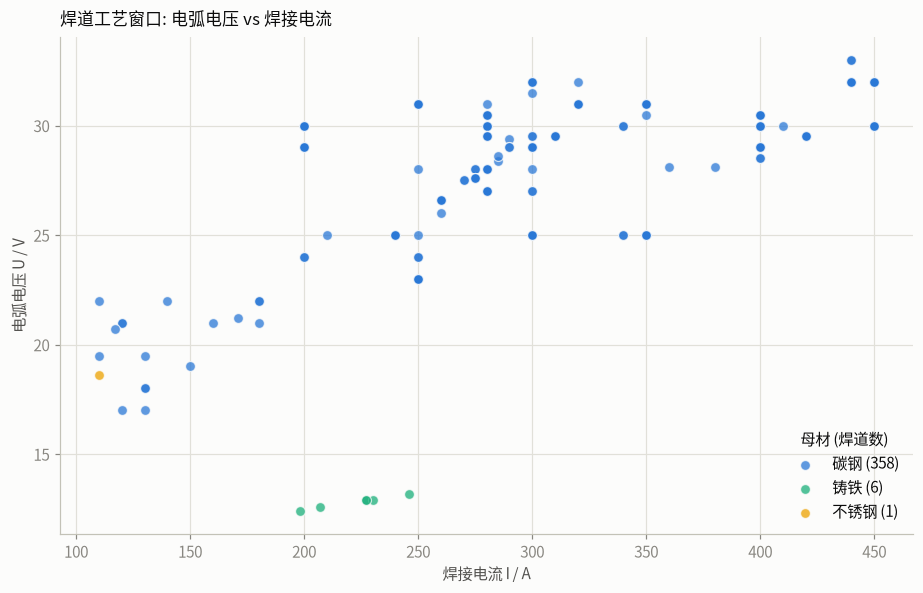

In [5]:
mat_order = rec["母材"].value_counts().index.tolist()
plaus = df[(df["电流A"].between(80, 450)) & (df["电压V"].between(10, 45))].copy()
plaus = plaus.join(rec["母材"].rename("母材_rec"), on="记录号")
print(f"参与绘图焊道: {len(plaus)} / {len(df)} (其余为缺失/一元化/无法解析)")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for i, m in enumerate(mat_order):
    g = plaus[plaus["母材_rec"] == m]
    if g.empty: continue
    ax.scatter(g["电流A"], g["电压V"], s=42, color=C[i], alpha=0.75,
               edgecolors="#fcfcfb", linewidths=0.8, label=f"{m} ({len(g)})")
ax.legend(title="母材 (焊道数)", frameon=False, loc="lower right")
style_ax(ax, title="焊道工艺窗口: 电弧电压 vs 焊接电流", xlabel="焊接电流 I / A", ylabel="电弧电压 U / V")
fig.tight_layout()
plt.show()

## 5. 焊接速度与线热输入

线热输入 $E = U \cdot I / v$ (kJ/mm, 未乘电弧效率; GMAW 典型 $\eta \approx 0.8$)。
导入时已按每焊道预存 `heat_input_J_mm` (单位 J/mm); 这里换算成 kJ/mm 作直方图。
$\eta U I$ 正是模块 4 `GoldakFDM` 双椭球热源的输入功率, $v$ 是热源移动速度 —
下面的分布给出了驱动热场仿真的**现实参数范围**。


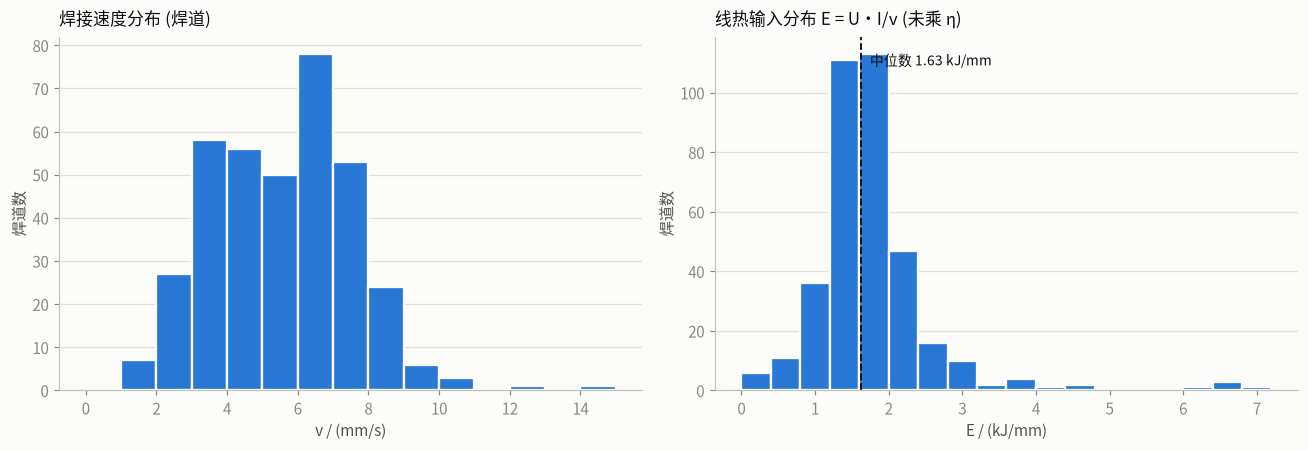

I: 110–450 A   U: 12.4–33.0 V   v: 1.1–15.0 mm/s   E 中位数: 1.63 kJ/mm (P10–P90: 1.00–2.48)


In [6]:
plaus["热输入kJ/mm"] = plaus["热输入J/mm"] / 1000
E = plaus["热输入kJ/mm"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(plaus["速度mm/s"].dropna(), bins=np.arange(0, 16, 1), color=C[0],
             edgecolor="#fcfcfb", linewidth=1.5)
style_ax(axes[0], title="焊接速度分布 (焊道)", xlabel="v / (mm/s)", ylabel="焊道数")

axes[1].hist(E, bins=np.arange(0, 7.5, 0.4), color=C[0], edgecolor="#fcfcfb", linewidth=1.5)
axes[1].axvline(E.median(), color=INK, linewidth=1.2, linestyle="--")
axes[1].text(E.median() + 0.12, axes[1].get_ylim()[1] * 0.92,
             f"中位数 {E.median():.2f} kJ/mm", color=INK, fontsize=9)
style_ax(axes[1], title="线热输入分布 E = U·I/v (未乘 η)", xlabel="E / (kJ/mm)", ylabel="焊道数")
for ax in axes: ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()
print(f"I: {plaus['电流A'].min():.0f}–{plaus['电流A'].max():.0f} A   "
      f"U: {plaus['电压V'].min():.1f}–{plaus['电压V'].max():.1f} V   "
      f"v: {plaus['速度mm/s'].min():.1f}–{plaus['速度mm/s'].max():.1f} mm/s   "
      f"E 中位数: {E.median():.2f} kJ/mm (P10–P90: {E.quantile(.1):.2f}–{E.quantile(.9):.2f})")

## 6. 摆动参数 (焊道级)

摆动在生产数据中非常普遍。点的大小 = 使用该 (频率, 幅值) 组合的焊道数
(参数取值高度离散, 直接散点会完全重叠)。


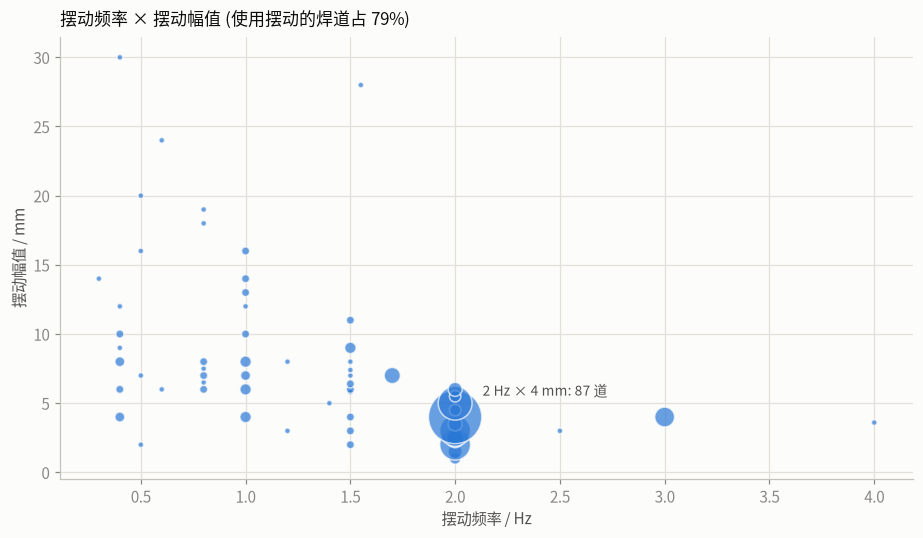

In [7]:
w = df[(df["摆频Hz"] > 0) & (df["摆幅mm"] > 0)]
share = len(w) / df["摆幅mm"].notna().sum()
grp = w.groupby(["摆频Hz", "摆幅mm"]).size().reset_index(name="n")

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.scatter(grp["摆频Hz"], grp["摆幅mm"], s=grp["n"] * 14, color=C[0], alpha=0.7,
           edgecolors="#fcfcfb", linewidths=1)
big = grp.nlargest(1, "n").iloc[0]
ax.annotate(f"{big['摆频Hz']:g} Hz × {big['摆幅mm']:g} mm: {big['n']:.0f} 道",
            (big["摆频Hz"], big["摆幅mm"]), textcoords="offset points",
            xytext=(18, 14), color=INK2, fontsize=9)
style_ax(ax, title=f"摆动频率 × 摆动幅值 (使用摆动的焊道占 {share:.0%})",
         xlabel="摆动频率 / Hz", ylabel="摆动幅值 / mm")
fig.tight_layout()
plt.show()

## 7. 摆动库: 路点波形

`weave_pattern` 文档用一个周期内的路点定义摆动波形: `time_pct` 为周期百分比,
`x/y/z_pct` 为幅值百分比 (Y 横向、Z 垂直), 另有角度与电流/电压调制 (本库中全为 0)。
下面从集合读回并重建前 12 个编号的波形。


摆动波形共 21 个, 编号: [107, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


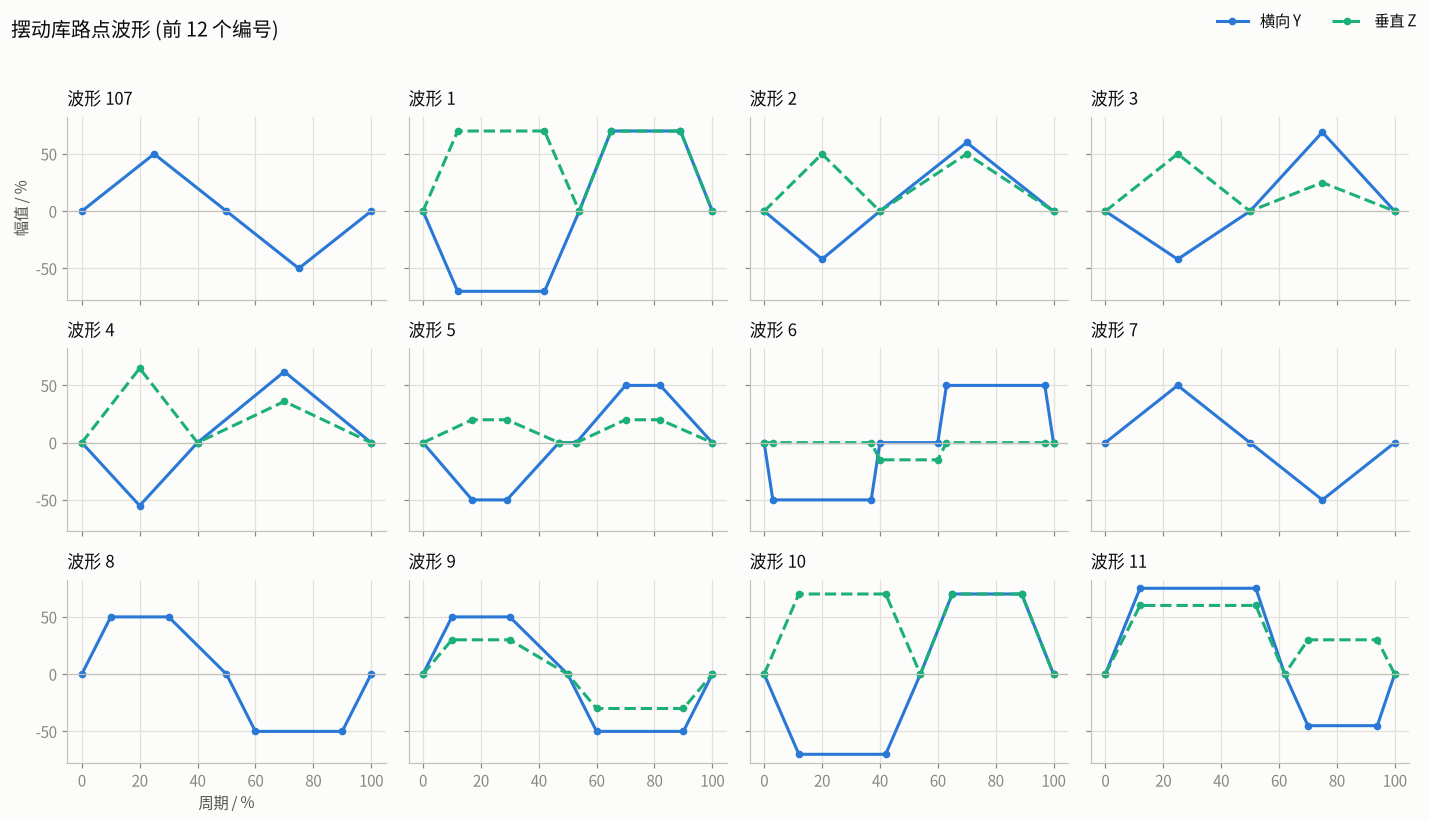

In [8]:
patterns = list(coll.find({"doc_type": "weave_pattern"}))  # 自然顺序 = 导入顺序 (107, 1, 2, …)
wl = pd.DataFrame([
    {"编号": d["pattern_id"], "点": p["point"], "时间%": p["time_pct"],
     "X%": p["x_pct"], "Y%": p["y_pct"], "Z%": p["z_pct"]}
    for d in patterns for p in d["waypoints"]
])
ids = wl["编号"].unique()
print(f"摆动波形共 {len(ids)} 个, 编号: {[int(x) for x in ids]}")

show = ids[:12]
fig, axes = plt.subplots(3, 4, figsize=(13, 7.5), sharex=True, sharey=True)
for ax, pid in zip(axes.ravel(), show):
    g = wl[wl["编号"] == pid].sort_values("时间%")
    t = np.r_[0, g["时间%"].values, 100]           # 闭合一个周期 (起点/终点回到 0)
    y = np.r_[0, g["Y%"].values, 0]
    z = np.r_[0, g["Z%"].values, 0]
    ax.plot(t, y, color=C[0], linewidth=2, marker="o", markersize=4)
    if np.abs(z).max() > 0:
        ax.plot(t, z, color=C[1], linewidth=2, marker="o", markersize=4, linestyle="--")
    ax.axhline(0, color=BASE, linewidth=0.8)
    style_ax(ax, title=f"波形 {pid:g}")
axes[0, 0].set_ylabel("幅值 / %")
axes[-1, 0].set_xlabel("周期 / %")
handles = [plt.Line2D([], [], color=C[0], lw=2, marker="o", ms=4, label="横向 Y"),
           plt.Line2D([], [], color=C[1], lw=2, marker="o", ms=4, ls="--", label="垂直 Z")]
fig.legend(handles=handles, loc="upper right", frameon=False, ncols=2)
fig.suptitle("摆动库路点波形 (前 12 个编号)", color=INK, x=0.01, ha="left", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 8. 录入规则与内嵌的焊机文件字段

`source_meta` 文档保存了原 xlsx"备注"表的录入规则; 各焊道的起弧/收弧/回烧文件参数
则内嵌在每个 `pass` 的 `arc_start` / `arc_end` / `burnback` 子文档中 (下面取一条非空样本)。


In [9]:
meta = coll.find_one({"doc_type": "source_meta"})
print("—— 录入规则 (source_meta.entry_notes) ——")
for line in meta["entry_notes"]:
    print(" ", line)

print("\n—— 内嵌焊机文件字段样本 (回烧 burnback 非空的焊道) ——")
sample = coll.find_one({"doc_type": "procedure", "passes.burnback.mode": {"$ne": None}})
p0 = next(p for p in sample["passes"] if p["burnback"]["mode"] is not None)
print(f"记录 {sample['record_id']} ({sample['machine']['model_raw']}) 焊道 {p0['pass_no']}:")
for key in ["arc_start", "arc_end", "burnback"]:
    print(f"  {key}: {p0[key]}")

—— 录入规则 (source_meta.entry_notes) ——
  1、输入信息为工作站信息、焊接设备、焊接材料、焊接方式
  2、输出焊接参数、摆动参数
  3、数据库工艺参数录入数据与用户查询使用数据库界面不同
  4、用户使用界面的输入信息为下拉菜单式
  5、录入数据时，输入、输出信息可复制、剪切、粘贴、插入、删除、查找、替换
  6、缺省用“*”标记
  7、视频、图片命名规则：项目号+工作站名称
  8、老版摆摆弧摆动形式标注为直线摆（老版摆摆弧摆动仅支持直线摆），新版摆弧摆动形式标注为摆动库文件名，具体摆动数据链接到“摆动库”表格中
  9、坡口尺寸/mm：坡口深度*角度；角焊缝无坡口尺寸；对接焊缝板厚*0°
  10、焊脚尺寸：角焊缝焊脚尺寸/mm：直角边*直角边，对接坡口焊缝焊脚尺寸/mm：余高*焊缝宽度
  11、林肯焊机控制送丝速度，单位:in/min；伏能士焊机控制送丝速度，单位:m/min,其它焊机控制电流，单位：A
  12、道数：单位道写1；多道焊：根道写0，覆盖道从1开始写（与多道焊模板对应）

—— 内嵌焊机文件字段样本 (回烧 burnback 非空的焊道) ——
记录 29 (奥太WSME315) 焊道 0:
  arc_start: {'current': None, 'voltage': None, 'file_no': None}
  arc_end: {'current': None, 'voltage': None, 'file_no': None}
  burnback: {'mode': '交流', 'workpoint': None, 'time': None, 'file_no': None}


## 9. 仿真实例化速查: 参数、工况与配置

前面各节是"数据库里有什么"; 本节是"怎么把它喂给仿真"。本仿真包**没有配置文件** —
每个模块都是自含类, 物理/工艺参数全部写在 `__init__` 里, 参数研究靠构造时覆盖 (`GoldakFDM(Q=..., v=...)`)。
模块之间只通过标量输出耦合 (如模块 1 的稳态功率驱动模块 4 的热源), 不共享全局状态。

据此, 实例化一次仿真需要的量分三类:

| 类别 | 含义 | 来源 |
|---|---|---|
| **A 工况参数** | 焊接规程决定的量: 电流、电弧电压/功率、焊接速度、干伸长、丝径、摆动 | **本数据库** (`passes.*` / `wire.*` / `source.stickout_mm`) |
| **B 材料与物性** | 母材/熔滴的 $\rho, c_p, k, \alpha, T_m, \gamma$; 电源静特性 $V_{oc}, R, L$; 电弧常数 $V_0, E_a, R_a$ | 手册值 / 电源标定, 数据库只给出母材与气体牌号 |
| **C 数值配置** | 网格 `dx`、域尺寸 `Lx/Ly/Lz`、时间步 `dt`/`h`、积分终点 `t_end`、求解器选择 | 由稳定性与精度要求决定, 与工艺无关 |

下面先从数据库取一个**代表工作点** (A 类), 再给出各模块 B/C 类参数的默认值总表。


In [10]:
# ---- A 类: 从数据库导出代表工作点 (中位工况: 碳钢 / 1.2 mm 实芯丝 / 82%Ar+18%CO2) ----
stick = pd.Series([d["source"]["stickout_mm"] for d in procs], dtype="float64").dropna()

def band(s):                                  # (P10, 中位, P90)
    s = s.dropna()
    return s.quantile(0.10), s.median(), s.quantile(0.90)

I_lo, I_md, I_hi = band(plaus["电流A"])
U_lo, U_md, U_hi = band(plaus["电压V"])
v_lo, v_md, v_hi = band(plaus["速度mm/s"])
E_lo, E_md, E_hi = band(plaus["热输入J/mm"])
s_lo, s_md, s_hi = band(stick)
f_lo, f_md, f_hi = band(w["摆频Hz"])
d_wire = rec["焊丝直径mm"].mode()[0]

# 仿真使用 SI 单位, 数据库为工程单位 -> 这里统一换算
OP = dict(I=I_md,                    # A
          U=U_md,                    # V
          Q=I_md * U_md,             # W   电弧功率 U·I -> 热源 Q
          v=v_md / 1e3,              # m/s  mm/s -> m/s
          rw=d_wire / 2e3,           # m    直径 mm -> 半径 m
          CTWD=s_md / 1e3)           # m    导电嘴-工件距离

win = pd.DataFrame([
    ("passes.current_A",        "A",    I_lo, I_md, I_hi, "I — 状态量 / DropletDynamics.simulate(I)"),
    ("passes.voltage_V",        "V",    U_lo, U_md, U_hi, "标定 GMAWDynamics.Voc / V0 / Ra"),
    ("U·I (导出)",              "W",    I_lo*U_lo, I_md*U_md, I_hi*U_hi, "GoldakFDM(Q=) / RosenthalThermal(Q=)"),
    ("passes.travel_speed_mm_s", "mm/s", v_lo, v_md, v_hi, "GoldakFDM(v=) / RosenthalThermal(v=) ÷1000"),
    ("passes.heat_input_J_mm",  "J/mm", E_lo, E_md, E_hi, "校核 η·Q/v, 不直接入参"),
    ("source.stickout_mm",      "mm",   s_lo, s_md, s_hi, "GMAWDynamics.simulate(CTWD_fun=) ÷1000"),
    ("passes.weave.frequency_Hz", "Hz", f_lo, f_md, f_hi, "摆动/脉冲激励频率 fp"),
], columns=["MongoDB 字段", "单位", "P10", "中位", "P90", "→ 仿真形参"])

print(f"焊丝直径众数 {d_wire:g} mm  ->  rw = {OP['rw']*1e3:.1f} mm "
      f"(与 GMAWDynamics / DropletDynamics 的默认 rw=0.6 mm 一致)")
print(f"干伸长 (stickout) 有值记录 {len(stick)}/{len(procs)} 条, 取中位 {s_md:g} mm")
win.round(1).set_index("MongoDB 字段")


焊丝直径众数 1.2 mm  ->  rw = 0.6 mm (与 GMAWDynamics / DropletDynamics 的默认 rw=0.6 mm 一致)
干伸长 (stickout) 有值记录 106/130 条, 取中位 20 mm


,单位,P10,中位,P90,→ 仿真形参
MongoDB 字段,,,,,
passes.current_A,A,200.0,280.0,420.0,I — 状态量 / DropletDynamics.simulate(I)
passes.voltage_V,V,25.0,29.0,31.0,标定 GMAWDynamics.Voc / V0 / Ra
U·I (导出),W,5000.0,8120.0,13020.0,GoldakFDM(Q=) / RosenthalThermal(Q=)
passes.travel_speed_mm_s,mm/s,3.0,5.2,7.5,GoldakFDM(v=) / RosenthalThermal(v=) ÷1000
passes.heat_input_J_mm,J/mm,1000.0,1626.7,2479.4,"校核 η·Q/v, 不直接入参"
source.stickout_mm,mm,18.0,20.0,25.0,GMAWDynamics.simulate(CTWD_fun=) ÷1000
passes.weave.frequency_Hz,Hz,1.0,2.0,2.0,摆动/脉冲激励频率 fp


### 9.2 各模块的构造参数与运行配置

**默认值即"典型碳钢 GMAW 工况"**, 与上表的数据库中位工况基本重合 (`Q=8200 W` vs 数据库 `U·I≈8120 W`; `rw=0.6 mm` vs 丝径众数 1.2 mm)。
下表列出全部可覆盖的参数; 粗体为**可由本数据库确定**的量, 其余为 B 类物性或 C 类数值配置。

| 模块 / 类 | 构造参数 (默认值) | 运行方法 (默认值) |
|---|---|---|
| 1 `GMAWDynamics` | *无构造形参*, 参数为实例属性: `Voc=32 V`, `Rs=Rl=0.004 Ω`, `Ls=3e-4 H`, `V0=15.5 V`, `Ea=800 V/m`, `Ra=0.022 Ω`, **`rw=0.6e-3 m`**, `k1=3e-4`, `k2=5e-5`, `rho_r=0.25 Ω/m` | `simulate(t_end=1.0, x0=(6e-3, 150.0), WFS_fun=λt:0.12, CTWD_fun=λt: 0.018+0.003·[t≥0.5])` — **送丝速度与 CTWD 阶跃经函数传入** |
| 2 `RosenthalThermal` | **`Q=8200 W`**, `eta=0.8`, **`v=8e-3 m/s`**, `k=41 W/(m·K)`, `alpha=8.7e-6 m²/s`, `T0=298 K`, `Tm=1773 K` | `surface_field(xlim=(-0.05,0.015), ylim=(-0.015,0.015), n=400)` |
| 3 `DropletDynamics` | **`rw=0.6e-3 m`**, `gamma=1.2 N/m`, `rho=7000`, `k1=3e-4`, `k2=5e-5`, `s=6e-3 m`, `rho_p=0.06`, `v_p=100 m/s`, `Cd=0.44` | `simulate(I, t_end=0.3, dt=2e-6)`; **`current_sweep(I_arr)`** — 扫过数据库的 200–420 A 区间即得滴状→射流过渡 |
| 4 `GoldakFDM` | **`Q=8200 W`**, `eta=0.8`, **`v=8e-3 m/s`**; 双椭球 `a=b=cf=4e-3`, `cr=9e-3 m`, `ff=0.6`; 域 `Lx=0.10, Ly=0.025, Lz=0.020 m`, `dx=1.25e-3 m`; `rho=7850`, `cp=600`, `k=41`, `T0=298`, `Tm=1773` | `run(t_end=5.0, x_start=0.015)` — `dt` 由显式稳定条件自动取 `0.4·dx²/(6α)`; `pool_size()` → (L, W, D) mm |
| 5 `ShortCircuitGMAW` | **`cmt=False\|True`** (唯一构造形参; 数据库中 20 条福尼斯/CMT 记录对应 `True`); 属性 `Voc=19 V`, `Rtot=0.012 Ω`, `Ls=1.5e-4 H`, **`WFS=0.080 m/s`**, **`CTWD=0.012 m`**, `la_short=0.4e-3`, `rb_min=0.12·rw`, `I_bg=45 A`, `I_boost=160 A`, `WFS_retract=-0.10 m/s` | `simulate(t_end=0.12, dt=2e-6)` → 数组 (t, I, V, phase) |
| 6 `DropletOscillatorVI` | `rd=0.5e-3 m`, `gamma=1.2`, `rho=7000`, `zeta=0.02`, `F0_frac=0.15`, `duty=0.35` | `run_vi(fp, t_end, h)` / `resonance_sweep(fp_arr, method="vi", periods=60, steps_per_period=22)` — **`fp` 为脉冲频率** |
| 7 `TwoLinkArm` | `m1=4.0, m2=2.5 kg`, `l1=0.40, l2=0.35 m`, `g=9.81` | `passive_compare(q0=(1.05,0.30), t_end=200.0, h=0.02)`; `seam_tracking(p_start=(0.30,0.10), p_end=(0.60,0.25), t_weld=4.0, h=0.01, Kp=120, Kd=24)` |
| 8 `ContactCycleVI` | `rd=0.5e-3`, `gamma=1.2`, `rho=7000`, `zeta=0.03`, `gap=0.4e-3 m`, **`v_feed=0.08`**, **`v_retract=0.10 m/s`**, `F_rup_frac=1.4` | `simulate_cycle(t_end=0.05, h=2e-6)`; `bounce_nonsmooth_vi(h=4e-6, e=0.85)` vs `bounce_penalty(k_pen_frac=2.5e4)` |
| 9 `OpenFOAMExporter` / `render` | `OpenFOAMExporter(fdm)` — 由一个已 `run()` 的 `GoldakFDM` 构造 | `export(case_dir, t_end=5.0)`; `render(fdm, field="peak"\|"final", offscreen=False, notebook=False, size=(1000,700), backend="auto")` |
| 10 Marangoni (dataclass) | `EffectiveMarangoniCorrection(dgamma_dT=-4e-4 N/(m·K), mu=6e-3 Pa·s, rho=7000, cp=780, k=30, pool_length=17.5e-3, pool_width=7.5e-3, limiter=6.0)`; `SurfaceMarangoniFlow2D(depth=3.8e-3, speed_limiter=1.5)`; `IncompressibleMarangoniFlow2D(cfl=0.25, speed_limiter=2.0)` | `alpha_eff(dT=700)`, `corrected_pool_size(L,W,D)`; `step(...)`, `stable_dt(...)` — **`pool_*` 应取 `GoldakFDM.pool_size()` 的输出** |
| — `variational` 核心 | `ForcedVerlet(m, grad_V, force=None)`; `MidpointDEL(lagrangian, n_dof, force=None, eps=1e-6)` | `run(q0, v0, t_end, h)` — 步长 `h` 是唯一数值旋钮; 勿替换为非辛格式 |

**注意数据库给不出的量**: 送丝速度 (WFS) 只在林肯记录里以"工作点"编码 (`current_raw` 如 `420（280A）`), 不是 m/min;
电源静特性 (`Voc`, `Ls`) 与电弧常数 (`V0`, `Ea`, `Ra`) 属于机型标定, 数据库仅记录型号;
熔滴尺度 `rd`、表面张力 `gamma`、$\partial\gamma/\partial T$ 均取手册值。这些保持模块默认即可。


In [11]:
# ---- 用数据库工作点实例化各模块, 并做一次自洽校核 ----
from welding_dynamics import (GMAWDynamics, RosenthalThermal, GoldakFDM,
                              DropletDynamics, ShortCircuitGMAW,
                              DropletOscillatorVI, ContactCycleVI,
                              EffectiveMarangoniCorrection)

# 模块 1: 无构造形参 -> 属性赋值覆盖 B 类; 工况 (WFS, CTWD) 经函数传入
g = GMAWDynamics(); g.rw = OP["rw"]
res1 = g.simulate(t_end=0.6, WFS_fun=lambda t: 0.12, CTWD_fun=lambda t: OP["CTWD"])
I_ss, U_ss, P_ss = res1["I"][-1], res1["Va"][-1], res1["P"][-1]

# 模块 2/4: 热源功率与移动速度直接取数据库中位值
ros = RosenthalThermal(Q=OP["Q"], v=OP["v"])
fdm = GoldakFDM(Q=OP["Q"], v=OP["v"])              # 仅实例化; run() 约需数十秒
E_raw = OP["Q"] / (OP["v"] * 1e3)                  # Q/v   [J/mm], 未乘 η
E_sim = 0.8 * E_raw                                # η·Q/v [J/mm], 实际入热

# 模块 3/5/6/8/10
dd = DropletDynamics(rw=OP["rw"])
F_gam, F_em = dd.F_gamma(), dd.F_em(OP["I"], dd.rw * 1.05)
sc = ShortCircuitGMAW(cmt=True)                    # 数据库中的福尼斯 CMT 记录
osc = DropletOscillatorVI(rd=0.5e-3)
cyc = ContactCycleVI(rd=0.5e-3)
mar = EffectiveMarangoniCorrection()

print(f"模块1 稳态      I={I_ss:5.0f} A   Ua={U_ss:4.1f} V   P={P_ss:5.0f} W")
print(f"   数据库中位   I={OP['I']:5.0f} A   U ={OP['U']:4.1f} V   U·I={OP['Q']:5.0f} W  <- 自调节工作点落在实测窗口内")
print(f"模块2/4 网格 {fdm.Nx}x{fdm.Ny}x{fdm.Nz} @ dx={fdm.dx*1e3:.2f} mm, 显式 dt={0.4*fdm.dx**2/(6*fdm.alpha)*1e3:.1f} ms")
print(f"   线热输入 Q/v={E_raw:.0f} J/mm (数据库中位 {E_md:.0f} J/mm), 乘 η=0.8 后实际入热 {E_sim:.0f} J/mm")
print(f"模块3 力平衡 @{OP['I']:.0f} A: F_em={F_em*1e3:.2f} mN > F_γ={F_gam*1e3:.2f} mN -> 射流过渡")
print(f"   数据库 P10–P90 = {I_lo:.0f}–{I_hi:.0f} A 恰好跨越滴状→射流过渡区 (current_sweep 的扫描范围)")
print(f"模块5 CMT: I_bg={sc.I_bg:.0f} A, I_boost={sc.I_boost:.0f} A, 送丝 {sc.WFS*60:.1f} m/min, 回抽 {sc.WFS_retract*60:.1f} m/min")
print(f"模块6/8 熔滴 Rayleigh 固有频率 f0={osc.f0:.0f} Hz; 数据库摆动 {w['摆频Hz'].min():.1f}–{w['摆频Hz'].max():.1f} Hz 低两个数量级 -> 摆动不激发该模态")
print(f"模块10 Marangoni: Ma={mar.strength()['Ma']:.0f}, α_eff/α={mar.alpha_eff()/mar.alpha:.1f} (limiter={mar.limiter:g} 已饱和)")


模块1 稳态      I=  272 A   Ua=29.1 V   P= 7908 W
   数据库中位   I=  280 A   U =29.0 V   U·I= 8120 W  <- 自调节工作点落在实测窗口内
模块2/4 网格 80x20x16 @ dx=1.25 mm, 显式 dt=12.0 ms
   线热输入 Q/v=1577 J/mm (数据库中位 1627 J/mm), 乘 η=0.8 后实际入热 1261 J/mm
模块3 力平衡 @280 A: F_em=5.30 mN > F_γ=4.52 mN -> 射流过渡
   数据库 P10–P90 = 200–420 A 恰好跨越滴状→射流过渡区 (current_sweep 的扫描范围)
模块5 CMT: I_bg=45 A, I_boost=160 A, 送丝 4.8 m/min, 回抽 -6.0 m/min
模块6/8 熔滴 Rayleigh 固有频率 f0=527 Hz; 数据库摆动 0.3–4.0 Hz 低两个数量级 -> 摆动不激发该模态
模块10 Marangoni: Ma=31850, α_eff/α=6.0 (limiter=6 已饱和)


### 9.3 端到端复现片段

把上面的工作点接成一条完整链路 (电弧 → 热源 → 熔池 → 导出), 即 `welding-sim` / `welding-sim-3d` 两个 CLI 的内核:

```python
import numpy as np
from welding_dynamics import GMAWDynamics, GoldakFDM, export_openfoam

# 1) 电弧自调节 -> 稳态功率 (A 类工况: CTWD 20 mm, WFS 0.12 m/s)
res = GMAWDynamics().simulate(t_end=1.0, CTWD_fun=lambda t: 0.020)
P_ss = float(np.mean(res["P"][1800:]))          # ≈ 7.9 kW

# 2) 双椭球热源: 功率来自模块 1, 速度来自数据库中位 5.15 mm/s
fdm = GoldakFDM(Q=P_ss, v=5.15e-3, dx=1.25e-3)
fdm.run(t_end=5.0)
print("熔池 L/W/D [mm]:", fdm.pool_size())

# 3) 导出 OpenFOAM 算例 (ParaView 直接打开 case.foam)
export_openfoam(fdm, "results/openfoam_case", t_end=5.0)
```

改工况只需改 `Q` 与 `v`: 例如取数据库的 P10/P90 边界 (`I·U` = 5.0 / 13.0 kW, `v` = 3.0 / 7.5 mm/s)
即可得到熔池尺寸的现实包络; 改 `dx` 只影响数值精度, 不改变物理。


## 10. 总结

**数据库概况** (2022-03 修订, 录入日期 2022-03-21 ~ 03-24), 现存于 MongoDB `welding_dynamics.welding_parameters`:

- **130 条焊接工艺记录 / 417 条焊道** (`procedure` 文档), 来自 32 家客户的真实生产项目; 单道焊记录 55 条 (42%), 多道焊每条最多 10 道 (根道 0 + 盖面道, 备注第 12 条)。
- **设备**: 以林肯 (Lincoln, ~64 条, 约一半) 为主, 其余为奥太、麦格米特、福尼斯/伏能士 (Fronius, 含 CMT 双丝)、乐驰、松下、米加尼克 — 覆盖了模块 5 中 CMT 短路过渡对应的机型。
- **工况高度集中**: 母材 91% 为碳钢 (另有铸铁、不锈钢、铝合金少量); 焊丝直径 87% 为 1.2 mm 实芯; 保护气体 86% 为 82%Ar+18%CO₂; 焊缝以角接/单V坡口、平焊/平角焊为主。
- **工艺窗口** (可解析焊道): I ≈ 110–450 A, U ≈ 12–33 V, v ≈ 1–15 mm/s; 线热输入 E=U·I/v 中位数 ≈ 1.6 kJ/mm (P10–P90 约 1.0–2.5)。少数行电流栏填的是送丝设定 (林肯 Workpoint), 实际电流在括号内 — 导入时已提取到 `current_A`, 原值保留在 `current_raw`; 福尼斯双丝记录取主丝。
- **摆动**: 约 79% 的焊道启用摆动, 典型组合 2 Hz × 4 mm; 摆动库含 21 个路点定义的波形 (`weave_pattern` 文档, 三角/梯形/斜锯齿等, 部分带垂直 Z 分量)。
- **辅助信息**: 录入规则存于 `source_meta`; 各焊道的起弧/收弧/回烧文件参数内嵌于 pass 的 `arc_start`/`arc_end`/`burnback` 子文档 (原 xlsx 中各品牌"文件"清单模板未单独入库)。

**MongoDB 文档模型 → 仿真模块对应**:

| 集合字段 | 仿真模块 | 用途 |
|---|---|---|
| `passes.current_A` / `voltage_V` (含林肯 WFS 原值 `current_raw`) | 模块 1 `GMAWDynamics` | 恒压特性工作点、自调节稳态校核 |
| `passes.heat_input_J_mm` 与 `travel_speed_mm_s` | 模块 4 `GoldakFDM` / `RosenthalThermal` | 双椭球热源功率与移动速度的现实取值域 |
| `passes.current_A` 范围 110–450 A | 模块 3 `DropletDynamics` | 覆盖滴状→射流过渡区 (current_sweep) |
| `machine.manufacturer` = Fronius/CMT 双丝记录 | 模块 5 `ShortCircuitGMAW`、模块 8 `ContactCycleVI` | CMT 模式参数佐证 |
| `passes.weave.*` + `weave_pattern` 波形 | 模块 4 `GoldakFDM(weave=...)` (`weave.py`: `HarmonicWeave` 直线摆 / `WaypointWeave` 路点波形; CLI 经 `weave=` 配置组启用, `pattern1` 逐字取自摆动库) | 驱动热源横向摆动 y_s(t), 自动切换全宽网格; 0.3–4 Hz 远低于熔滴共振频率, 不激发模块 6 模态 |

**数据质量提示**: 导入时已把送丝设定/双丝/`一元化` 等格式清洗为数值字段, 原值保留在 `*_raw`;
仍有约 13% 焊道缺完整 I/U/v (`current_A`/`voltage_V` 为 `null`)。解析规则见 [`project_data/ingest_mongo.py`](../project_data/ingest_mongo.py);
重新导入 (数据修订后) 运行该脚本即可幂等重建集合。
